# Exploring dataset inspection with pySTAMPS

This notebook teaches the safest first interaction with pySTAMPS: inspecting a dataset before you process anything.

If you are new to interferometry, think of this as the equivalent of checking the folder structure and current progress before pressing a run button.


## Why inspection matters

A pySTAMPS dataset is not just a random directory of files. The folder layout tells pySTAMPS:

- where the patch-level workspaces are
- which stage outputs already exist
- whether the merged outputs have started to appear

The `status` command reads this structure and summarizes what pySTAMPS sees.


In [1]:
from pathlib import Path

DATASET_MAIN = Path('inputs_and_outputs/InSAR_dataset_test')
DATASET_STAGE8 = Path('inputs_and_outputs/InSAR_dataset_test_stage8diag')

for path in (DATASET_MAIN, DATASET_STAGE8):
    print(f'{path}:', 'present' if path.exists() else 'missing')


inputs_and_outputs/InSAR_dataset_test: present
inputs_and_outputs/InSAR_dataset_test_stage8diag: present


## Inspect raw patch artifacts

This notebook reads the tracked patch-level files directly instead of depending on generated `.mat` outputs.

The inspection uses three source files from each patch folder:

- `pscands.1.ij` for candidate row and column positions
- `pscands.1.da` for the D_A stability statistic
- `pscands.1.ll` for geographic longitude and latitude


In [2]:
from __future__ import annotations

from datetime import datetime, date
from pathlib import Path
import re

import numpy as np

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt
except Exception as exc:
    plt = None
    mdates = None
    MATPLOTLIB_IMPORT_ERROR = exc

PATCH_RE = re.compile(r'^PATCH_(\d+)$')
DATE_RE = re.compile(r'^(?P<date>\d{8})\.rslc(?:\.par)?$')


def _patch_index(path: Path) -> int:
    match = PATCH_RE.match(path.name)
    return int(match.group(1)) if match else 10**9


def _load_text_matrix(path: Path) -> np.ndarray:
    values = np.loadtxt(path)
    return np.atleast_2d(values)


def _load_text_vector(path: Path) -> np.ndarray:
    values = np.loadtxt(path)
    return np.asarray(values, dtype=np.float64).reshape(-1)


def _binary_float32_endian(path: Path) -> str:
    sample_count = min(max(32, path.stat().st_size // 4), 512)
    sample_le = np.fromfile(path, dtype='<f4', count=sample_count)
    sample_be = np.fromfile(path, dtype='>f4', count=sample_count)

    def _score(arr: np.ndarray) -> tuple[float, float]:
        finite = np.isfinite(arr)
        if not finite.any():
            return (-1.0, float('-inf'))
        arr_f = np.asarray(arr[finite], dtype=np.float64)
        finite_ratio = float(np.mean(finite))
        abs_arr = np.abs(arr_f)
        plausible = np.logical_or(abs_arr == 0.0, np.logical_and(abs_arr >= 1e-12, abs_arr <= 1e12))
        return (finite_ratio + float(np.mean(plausible)), -float(np.nanmedian(abs_arr)))

    return '>f4' if _score(sample_be) > _score(sample_le) else '<f4'


def _load_lonlat(path: Path) -> np.ndarray:
    values = np.fromfile(path, dtype=_binary_float32_endian(path)).astype(np.float64, copy=False)
    if values.size % 2:
        raise ValueError(f'{path} does not contain an even number of float32 values')
    lonlat = values.reshape(-1, 2)
    return lonlat[np.isfinite(lonlat).all(axis=1)]


def _acquisition_dates(dataset_root: Path) -> list[date]:
    values: list[date] = []
    for path in sorted((dataset_root / 'rslc').glob('*.rslc*')):
        match = DATE_RE.match(path.name)
        if match:
            values.append(datetime.strptime(match.group('date'), '%Y%m%d').date())
    return sorted(dict.fromkeys(values))


def _inspect_patch(patch_dir: Path) -> dict[str, object]:
    ij = _load_text_matrix(patch_dir / 'pscands.1.ij')
    da = _load_text_vector(patch_dir / 'pscands.1.da')
    lonlat = _load_lonlat(patch_dir / 'pscands.1.ll')

    candidate_count = int(ij.shape[0])
    if da.size != candidate_count:
        raise ValueError(f'{patch_dir.name}: expected {candidate_count} D_A values, found {da.size}')
    if lonlat.shape[0] != candidate_count:
        raise ValueError(f'{patch_dir.name}: expected {candidate_count} lon/lat rows, found {lonlat.shape[0]}')

    return {
        'name': patch_dir.name,
        'count': candidate_count,
        'ij': ij,
        'da': da,
        'lonlat': lonlat,
        'row_min': float(np.min(ij[:, 1])),
        'row_max': float(np.max(ij[:, 1])),
        'col_min': float(np.min(ij[:, 2])),
        'col_max': float(np.max(ij[:, 2])),
        'da_min': float(np.min(da)),
        'da_median': float(np.median(da)),
        'da_mean': float(np.mean(da)),
        'da_max': float(np.max(da)),
        'lon_min': float(np.min(lonlat[:, 0])),
        'lon_max': float(np.max(lonlat[:, 0])),
        'lat_min': float(np.min(lonlat[:, 1])),
        'lat_max': float(np.max(lonlat[:, 1])),
    }


def inspect_dataset(dataset_root: Path) -> dict[str, object]:
    patch_dirs = sorted((p for p in dataset_root.glob('PATCH_*') if p.is_dir()), key=_patch_index)
    patches = [_inspect_patch(patch_dir) for patch_dir in patch_dirs]
    acquisition_dates = _acquisition_dates(dataset_root)
    all_da = np.concatenate([patch['da'] for patch in patches]) if patches else np.array([], dtype=np.float64)
    all_lonlat = np.concatenate([patch['lonlat'] for patch in patches]) if patches else np.empty((0, 2), dtype=np.float64)

    return {
        'root': dataset_root,
        'patches': patches,
        'patch_count': len(patches),
        'candidate_count': int(sum(patch['count'] for patch in patches)),
        'acquisition_dates': acquisition_dates,
        'all_da': all_da,
        'all_lonlat': all_lonlat,
    }


In [3]:
INSPECTIONS = {
    'main': inspect_dataset(DATASET_MAIN),
    'stage8diag': inspect_dataset(DATASET_STAGE8),
}

for label, data in INSPECTIONS.items():
    dates = data['acquisition_dates']
    patches = data['patches']
    print(f'[{label}]')
    print(f"  patches: {data['patch_count']}")
    print(f"  candidates: {data['candidate_count']}")
    print(f"  acquisitions: {len(dates)}")
    if dates:
        print(f'  acquisition range: {dates[0]} -> {dates[-1]}')
    if patches:
        counts = ', '.join(f"{patch['name']}={patch['count']}" for patch in patches)
        print(f'  per-patch counts: {counts}')
        print(
            '  D_A range: '
            f"{min(patch['da_min'] for patch in patches):.6f} -> "
            f"{max(patch['da_max'] for patch in patches):.6f}"
        )
        print(
            '  lon/lat range: '
            f"{min(patch['lon_min'] for patch in patches):.4f}, {min(patch['lat_min'] for patch in patches):.4f} -> "
            f"{max(patch['lon_max'] for patch in patches):.4f}, {max(patch['lat_max'] for patch in patches):.4f}"
        )
    print()


[main]
  patches: 4
  candidates: 640476
  acquisitions: 76
  acquisition range: 2023-03-04 -> 2025-08-20
  per-patch counts: PATCH_1=81428, PATCH_2=223357, PATCH_3=165271, PATCH_4=170420
  D_A range: 0.091943 -> 0.400000
  lon/lat range: 10.6321, 44.4275 -> 11.7433, 44.7478

[stage8diag]
  patches: 4
  candidates: 640476
  acquisitions: 67
  acquisition range: 2023-03-04 -> 2025-05-04
  per-patch counts: PATCH_1=81428, PATCH_2=223357, PATCH_3=165271, PATCH_4=170420
  D_A range: 0.091943 -> 0.400000
  lon/lat range: 10.6321, 44.4275 -> 11.7433, 44.7478



## What the plot shows

The figure below combines statistics and geography in one place:

- candidate counts by patch
- the D_A distribution across the tracked patch files
- the spatial footprint of candidate points on longitude and latitude
- the acquisition dates found in the `rslc` directory


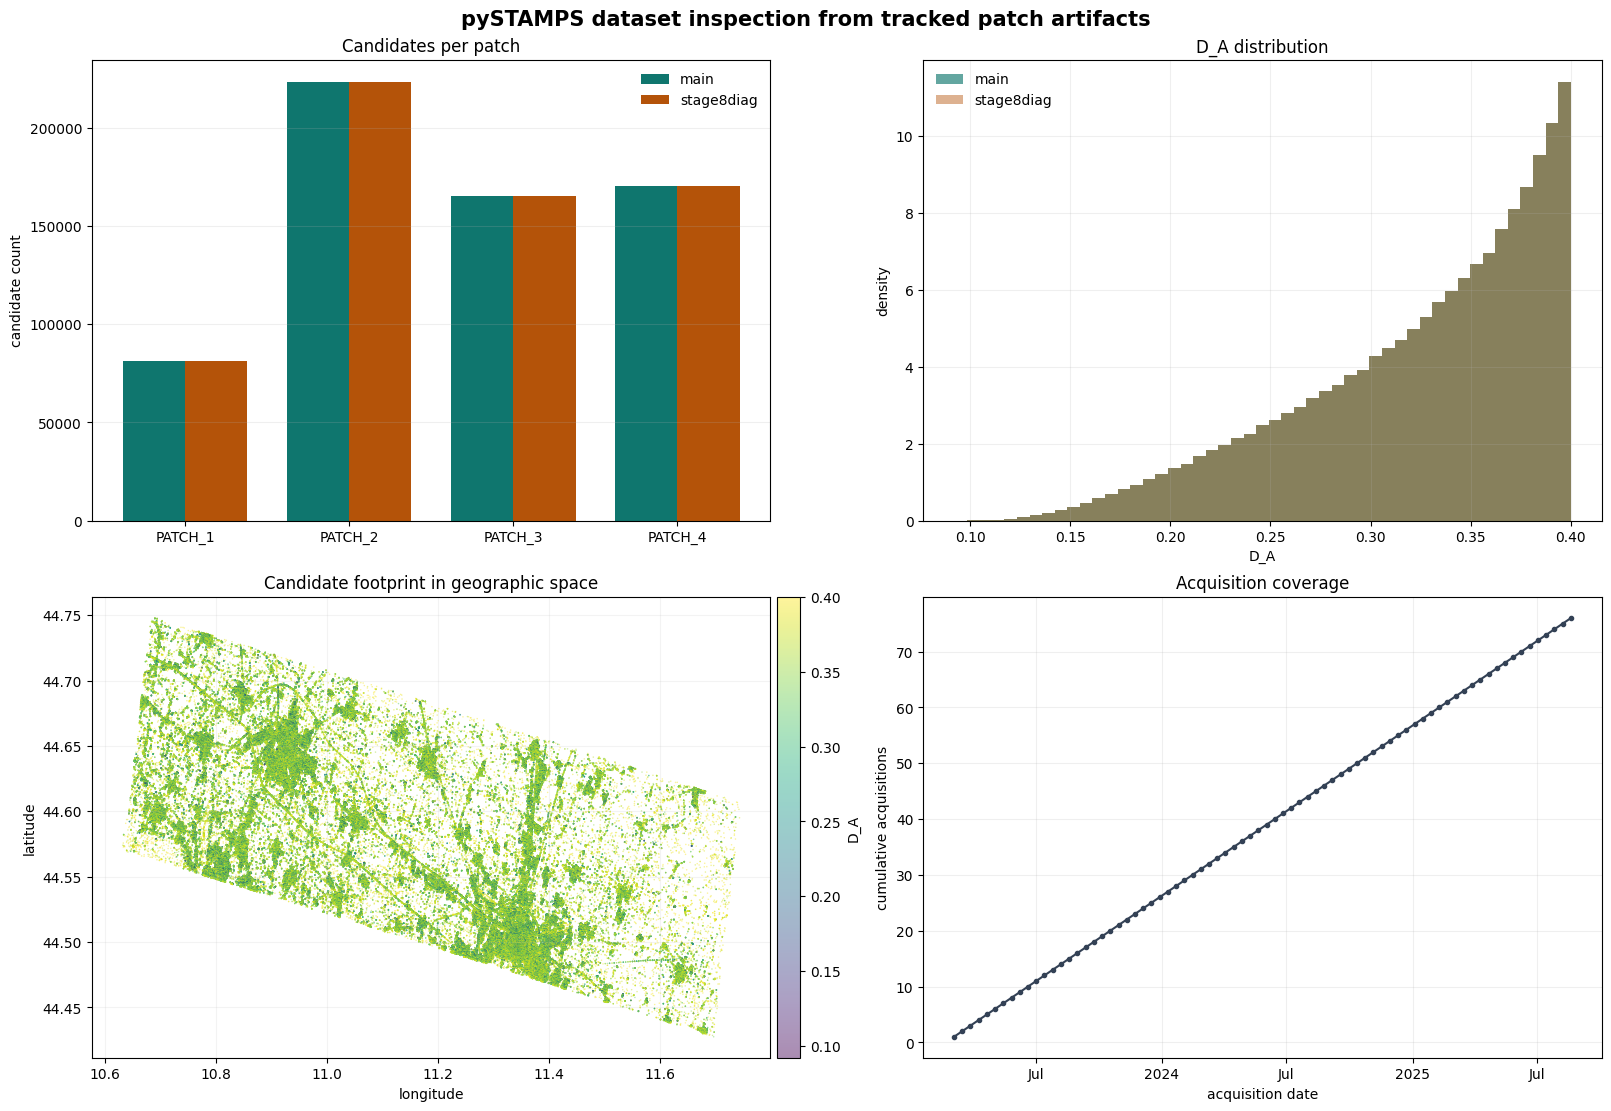

In [4]:
if plt is None:
    print('matplotlib is not available in this environment.')
    print(f'Import error: {MATPLOTLIB_IMPORT_ERROR}')
else:
    main = INSPECTIONS['main']
    stage8 = INSPECTIONS['stage8diag']
    patch_names = [patch['name'] for patch in main['patches']]
    patch_x = np.arange(len(patch_names))
    width = 0.38

    fig, axes = plt.subplots(2, 2, figsize=(16, 11), constrained_layout=True)
    fig.suptitle('pySTAMPS dataset inspection from tracked patch artifacts', fontsize=15, fontweight='bold')

    ax = axes[0, 0]
    ax.bar(patch_x - width / 2, [patch['count'] for patch in main['patches']], width, label='main', color='#0f766e')
    ax.bar(patch_x + width / 2, [patch['count'] for patch in stage8['patches']], width, label='stage8diag', color='#b45309')
    ax.set_xticks(patch_x, patch_names)
    ax.set_ylabel('candidate count')
    ax.set_title('Candidates per patch')
    ax.grid(axis='y', alpha=0.2)
    ax.legend(frameon=False)

    ax = axes[0, 1]
    all_da = np.concatenate([main['all_da'], stage8['all_da']])
    bins = np.linspace(float(np.min(all_da)), float(np.max(all_da)), 50)
    ax.hist(main['all_da'], bins=bins, alpha=0.65, density=True, label='main', color='#0f766e')
    ax.hist(stage8['all_da'], bins=bins, alpha=0.45, density=True, label='stage8diag', color='#b45309')
    ax.set_xlabel('D_A')
    ax.set_ylabel('density')
    ax.set_title('D_A distribution')
    ax.grid(alpha=0.2)
    ax.legend(frameon=False)

    ax = axes[1, 0]
    lon = main['all_lonlat'][:, 0]
    lat = main['all_lonlat'][:, 1]
    scatter = ax.scatter(lon, lat, c=main['all_da'], s=1.2, cmap='viridis', alpha=0.45, linewidths=0)
    ax.set_xlabel('longitude')
    ax.set_ylabel('latitude')
    ax.set_title('Candidate footprint in geographic space')
    ax.grid(alpha=0.15)
    cbar = fig.colorbar(scatter, ax=ax, pad=0.01)
    cbar.set_label('D_A')

    ax = axes[1, 1]
    dates = main['acquisition_dates']
    if dates:
        plot_dates = [datetime.combine(value, datetime.min.time()) for value in dates]
        ax.plot(plot_dates, np.arange(1, len(dates) + 1), '-', color='#334155', linewidth=1.5, marker='o', markersize=3)
        locator = mdates.AutoDateLocator(minticks=4, maxticks=8)
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
    ax.set_title('Acquisition coverage')
    ax.set_xlabel('acquisition date')
    ax.set_ylabel('cumulative acquisitions')
    ax.grid(alpha=0.2)

    plt.show()


## Peek at the top-level folder entries

This cell is safe. It only lists some names from the main reference dataset if the path exists.


In [5]:
if DATASET_MAIN.exists():
    entries = sorted(path.name for path in DATASET_MAIN.iterdir())
    print('Top-level entries in the reference dataset:')
    for name in entries[:25]:
        print(' -', name)
else:
    print('Reference dataset not present in this checkout.')


Top-level entries in the reference dataset:
 - .cache
 - .gitattributes
 - PATCH_1
 - PATCH_2
 - PATCH_3
 - PATCH_4
 - STAMPS.log
 - bp2.mat
 - calamp.in
 - calamp.out
 - dem
 - diff0
 - geo
 - header
 - hgt2.mat
 - ifgstd2.mat
 - inc2.mat
 - la2.mat
 - len.txt
 - mean_v.mat
 - mv2.mat
 - no_ps_info.mat
 - parms.mat
 - patch.list
 - patch.list_old


## Look for patch folders

Patch folders are commonly named `PATCH_1`, `PATCH_2`, and so on. They hold patch-level artifacts used by several stages.


In [6]:
if DATASET_MAIN.exists():
    patch_dirs = sorted(path.name for path in DATASET_MAIN.glob('PATCH_*') if path.is_dir())
    print('Patch directories:')
    for name in patch_dirs:
        print(' -', name)
else:
    print('Reference dataset not present in this checkout.')


Patch directories:
 - PATCH_1
 - PATCH_2
 - PATCH_3
 - PATCH_4


## The first pySTAMPS command to learn

Use `status` before `run`.

Why this helps:

- it is read-only
- it tells you whether pySTAMPS recognizes the dataset
- it gives you a stage-oriented summary before you commit to processing


In [7]:
status_command = 'uv run pystamps status --dataset inputs_and_outputs/InSAR_dataset_test'
print(status_command)


uv run pystamps status --dataset inputs_and_outputs/InSAR_dataset_test


## What to look for in a status result

A status report is most useful when you read it as answers to three simple questions:

1. Did pySTAMPS find the dataset root I intended?
2. How many patch directories did it detect?
3. Which stage seems to be the latest completed stage for the patch and merged outputs?

If those answers look wrong, stop there and fix the dataset path or layout before trying any execution command.


## Next step

After inspection, move to `pystamps_stage_execution.ipynb` to learn how to preview a run with `--dry-run`.
